# Physics Simulation and Fitness Evaluation

Kinematic foot-loci (notebook 01) are free but they don't tell you
whether the walker **actually walks**. For that we drop the Walker
into a pymunk physics `World`, let it step for a few simulated
seconds, and score how far it got.

**What you'll learn:**
- Configuring gravity, friction, and terrain with `WorldConfig` / `TerrainConfig`
- Running a simulated walk with `World` + `Walker`
- Three built-in fitness evaluators (`DistanceFitness`,
  `EfficiencyFitness`, `StrideFitness`) and when each one applies
- Generating obstacle and slope terrains from `TerrainPreset`


In [1]:
import warnings

import matplotlib.pyplot as plt

import leggedsnake as ls

warnings.filterwarnings('ignore', category=DeprecationWarning)


## 1. The `WorldConfig` dataclass

Before `0.5.0`, physics parameters lived in a module-level `params`
dict. They now live on a `WorldConfig` dataclass you pass into `World()`
(the old `params` dict is still populated for legacy scripts). Defaults
match the historical dict: Earth gravity, 1000 N·m motor torque,
`physics_period=0.02`.


In [2]:
cfg = ls.WorldConfig()
print(f"gravity = {cfg.gravity} m/s²")
print(f"physics period = {cfg.physics_period} s")
print(f"torque = {cfg.torque} N·m, load = {cfg.load_mass} kg")
print(f"terrain: slope={cfg.terrain.slope:.3f} rad, noise={cfg.terrain.noise}")


gravity = (0, -9.80665) m/s²
physics period = 0.02 s
torque = 1000.0 N·m, load = 10.0 kg
terrain: slope=0.175 rad, noise=0.9


## 2. Simulate a Jansen walker for a few seconds

`World(config=...).add_linkage(walker)` converts the kinematic Walker
to its pymunk-backed twin, drops it on the road, and stands ready to
step. We bump the Jansen walker to four legs so it has enough ground
contact for a stable gait.


In [3]:
def simulate(walker, duration_s=3.0, config=None):
    # Step the walker in a fresh World and return the final body x.
    cfg = config or ls.WorldConfig()
    world = ls.World(config=cfg)
    world.add_linkage(walker)
    n_steps = int(duration_s / cfg.physics_period)
    for _ in range(n_steps):
        world.update()
    return world.linkages[0].body.position.x

jansen = ls.Walker.from_jansen(scale=0.5)
jansen.add_legs(3)  # four legs total
x = simulate(jansen, duration_s=3.0)
print(f"Jansen travelled {x:.2f} m in 3 simulated seconds")


Jansen travelled -0.12 m in 3 simulated seconds


## 3. The `DynamicFitness` protocol

Optimizers need a *single number*. `DynamicFitness` is a Protocol:
any callable with signature `(topology, dimensions, config) → FitnessResult`
qualifies. Leggedsnake ships three implementations:

| Fitness            | Physics? | Maximizes                          |
|--------------------|----------|-------------------------------------|
| `StrideFitness`    | No       | Kinematic horizontal stride         |
| `DistanceFitness`  | Yes      | Total distance walked in T seconds  |
| `EfficiencyFitness`| Yes      | Distance / energy consumed          |

`CompositeFitness` evaluates distance + efficiency + stability in a
**single physics run**, so NSGA-II with three objectives costs one
simulation per candidate instead of three.


In [4]:
fit_distance = ls.DistanceFitness(duration=3.0, n_legs=4)
fit_efficiency = ls.EfficiencyFitness(duration=3.0, n_legs=4, min_distance=0.5)
fit_stride = ls.StrideFitness()

walker = ls.Walker.from_jansen(scale=0.5)
for fit in (fit_distance, fit_efficiency, fit_stride):
    r = fit(walker.topology, walker.dimensions, ls.WorldConfig())
    print(f"{type(fit).__name__:20s} score={r.score:8.3f}  valid={r.valid}  metrics={dict(r.metrics)}")


DistanceFitness      score=   0.122  valid=True  metrics={'distance': 0.12226918132005106, 'total_efficiency': 198.75472119688237, 'total_energy': 7.876854908747177}
EfficiencyFitness    score=   0.000  valid=True  metrics={'distance': 0.09701482442279358, 'total_efficiency': 59.422980416098426, 'total_energy': 11.272758199019634, 'efficiency_ratio': 0.0}
StrideFitness        score=  13.588  valid=True  metrics={'stride_length': 13.58845825499473, 'obstacle_clearance': 1.0}


## 4. Terrain presets

`TerrainConfig` exposes a library of rough-ground generators. The
`TerrainPreset` enum gives five ready-made configurations:


In [5]:
for preset in ls.TerrainPreset:
    t = ls.TerrainConfig.from_preset(preset)
    print(f"{preset.name:10s} slope={t.slope:+.3f}rad  noise={t.noise:.2f}  "
          f"gap={t.gap_freq:.2f}  obstacle={t.obstacle_freq:.2f}  "
          f"profile={t.slope_profile}")


FLAT       slope=+0.000rad  noise=0.00  gap=0.00  obstacle=0.00  profile=SlopeProfile.FLAT
HILLY      slope=+0.262rad  noise=0.60  gap=0.00  obstacle=0.00  profile=SlopeProfile.RANDOM
ROUGH      slope=+0.087rad  noise=1.00  gap=0.00  obstacle=0.15  profile=SlopeProfile.RANDOM
STAIRS     slope=+0.000rad  noise=0.00  gap=0.00  obstacle=0.00  profile=SlopeProfile.RANDOM
MIXED      slope=+0.175rad  noise=0.90  gap=0.05  obstacle=0.10  profile=SlopeProfile.RANDOM


## 5. Walk on rough vs flat ground

Ground roughness costs distance. We simulate the same Jansen walker
on three presets and compare.


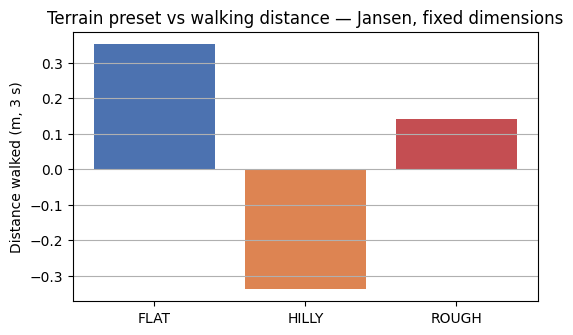

In [6]:
results = {}
for preset in (ls.TerrainPreset.FLAT, ls.TerrainPreset.HILLY, ls.TerrainPreset.ROUGH):
    cfg = ls.WorldConfig(terrain=ls.TerrainConfig.from_preset(preset))
    walker = ls.Walker.from_jansen(scale=0.5)
    walker.add_legs(3)
    results[preset.name] = simulate(walker, duration_s=3.0, config=cfg)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(results.keys(), results.values(), color=['#4c72b0', '#dd8452', '#c44e52'])
ax.set_ylabel("Distance walked (m, 3 s)")
ax.set_title("Terrain preset vs walking distance — Jansen, fixed dimensions")
ax.grid(True, axis='y')
plt.show()


## Summary

- **`WorldConfig` + `TerrainConfig`** are the structured entry points
  — pass one into `World(config=...)` instead of mutating the global
  `params` dict.
- **Fitness evaluators** implement `DynamicFitness`. Prefer
  `StrideFitness` (kinematic, cheap) inside inner loops and
  `DistanceFitness` / `CompositeFitness` (physics, expensive) for the
  decisive scoring pass.
- **Terrain presets** keep benchmarks reproducible (they carry a
  `seed`), which matters when comparing two candidates or re-scoring
  a checkpoint.

Next (notebook 03): run a GA over the Strider's link lengths to find
a better walker.
